In [154]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, roc_auc_score

In [155]:
df = pd.read_csv('spam.csv', encoding='latin1')
df.dropna(axis=1, inplace=True)
df = df[df.columns[::-1]]
df.columns = ['text', 'label']
df.head()


,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [156]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5169 non-null   object
 1   label   5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


In [157]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


In [158]:
df['label'].value_counts(normalize=True) * 100

,proportion
label,
ham,87.366996
spam,12.633004




---


**Notice an implanace for spam and non-spam text this needs correction**

---



In [159]:
df['text'].str.len().describe()


,text
count,5169.000000
mean,78.977945
std,58.236293
min,2.000000
25%,36.000000
50%,60.000000
75%,117.000000
max,910.000000


# Train Test Split

In [160]:
x = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Length Of X_train {len(X_train)}")
print(f"Length Of X_test {len(X_test)}")

Length Of X_train 4135
Length Of X_test 1034


# TF-IDF Vectorizing

In [161]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4135, 7591)
(1034, 7591)



.
.
.
.




---

# **KNN (K nearest neighbors)**



---
.
.
.
.

In [162]:
model = KNeighborsClassifier(n_neighbors=5, weights='distance')

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

accuracy_score(y_test, y_pred)

0.9245647969052224

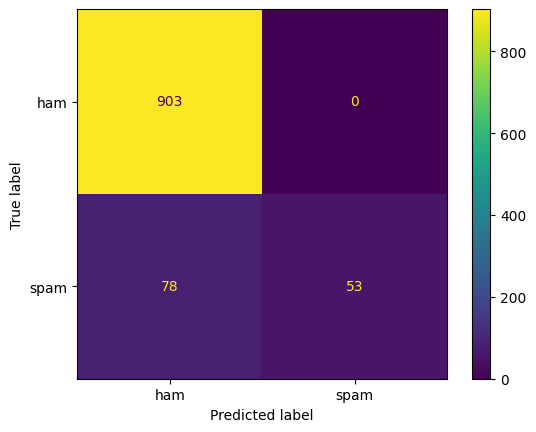

In [163]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


# Logistic Regression

**Note:**  class_weight="balanced" solve our data imblanace by giving more    weight for the minority class of spams

In [164]:
model_lr = LogisticRegression(C=100, class_weight="balanced")

model_lr.fit(X_train_tfidf, y_train)

y_pred= model_lr.predict(X_test_tfidf)


# Logistic Regression metrics


In [165]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.94      0.91      0.92       131

    accuracy                           0.98      1034
   macro avg       0.96      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



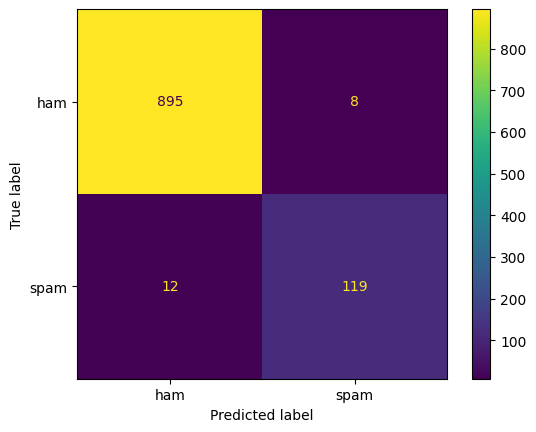

In [166]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [167]:
y_prob = model_lr.predict_proba(X_test_tfidf)[:, 1]

roc_auc_score(y_test, y_prob)

np.float64(0.9900416761769504)

# Top 10 impactful words to flag a message as spam


In [168]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model_lr.coef_[0]


features = pd.DataFrame({
    'word': feature_names,
    'weight': coefficients
})
features.sort_values('weight', ascending=False).head(10)

,word,weight
6949,txt,15.046011
1721,chat,12.468937
6640,text,12.062305
5601,reply,11.100213
1800,claim,10.982843
6975,uk,10.885136
7474,www,10.542729
6360,stop,10.397923
516,50,10.254908
4483,mobile,10.131320


# Testing with custom message

In [169]:
my_message_spam = ["You Have won a 399$ tv collect your prize by contacting us at 0501205987"]
my_mesaage_ham = ["are we still up for tommorow?"]

my_message_spam_tfidf = vectorizer.transform(my_message_spam)
my_mesaage_ham_tfidf = vectorizer.transform(my_mesaage_ham)


print(my_message_spam, model_lr.predict(my_message_spam_tfidf))
print(my_mesaage_ham, model_lr.predict(my_mesaage_ham_tfidf))


['You Have won a 399$ tv collect your prize by contacting us at 0501205987'] ['spam']
['are we still up for tommorow?'] ['ham']
